โหลดข้อมูล (Load Data)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, validation_curve, learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler 
from sklearn.linear_model import LinearRegression 
from sklearn.pipeline import make_pipeline

df = pd.read_csv('/Users/teesinad/Documents/school/DataSci/ClassWork/DataSciPython/RealestateAnalize/dataset/Real_estate.csv')

print(df.head())
print(df.describe())
print(df.info())

target_variable = 'house price of unit area'
features = [
    'transaction date',
    'house age',
    'distance to the nearest MRT station',
    'number of convenience stores',
    'latitude',
    'longitude'
]

X = df[features]
y = df[target_variable]

   No  transaction date  house age  distance to the nearest MRT station  \
0   1          2012.917       32.0                             84.87882   
1   2          2012.917       19.5                            306.59470   
2   3          2013.583       13.3                            561.98450   
3   4          2013.500       13.3                            561.98450   
4   5          2012.833        5.0                            390.56840   

   number of convenience stores  latitude  longitude  house price of unit area  
0                            10  24.98298  121.54024                      37.9  
1                             9  24.98034  121.53951                      42.2  
2                             5  24.98746  121.54391                      47.3  
3                             5  24.98746  121.54391                      54.8  
4                             5  24.97937  121.54245                      43.1  
               No  transaction date   house age  \
count  414.0

สำรวจข้อมูลเบื้องต้น (Data Understanding)

In [15]:
print(df.isnull().sum())

numerical_cols = X.select_dtypes(include=np.number).columns
imputer_numerical = SimpleImputer(strategy='mean')
X.loc[:, numerical_cols] = imputer_numerical.fit_transform(X[numerical_cols])

print(X.isnull().sum())


No                                     0
transaction date                       0
house age                              0
distance to the nearest MRT station    0
number of convenience stores           0
latitude                               0
longitude                              0
house price of unit area               0
dtype: int64
transaction date                       0
house age                              0
distance to the nearest MRT station    0
number of convenience stores           0
latitude                               0
longitude                              0
dtype: int64


เตรียมข้อมูล (Data Preparation)

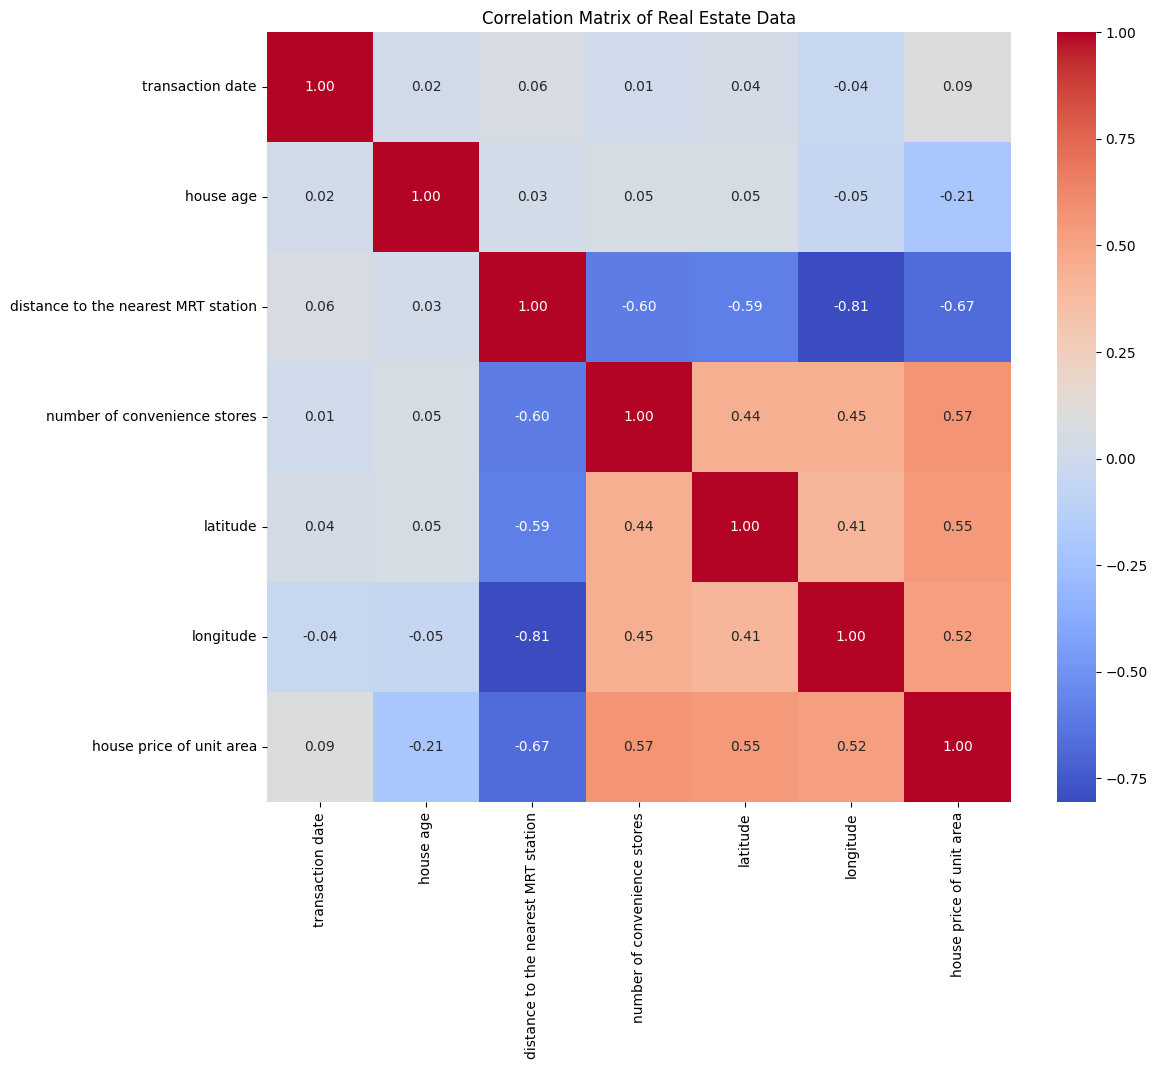

In [16]:
plt.figure(figsize=(12, 10))
correlation_data = df[features + [target_variable]]
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Real Estate Data')
plt.show()

Correlation Matrix

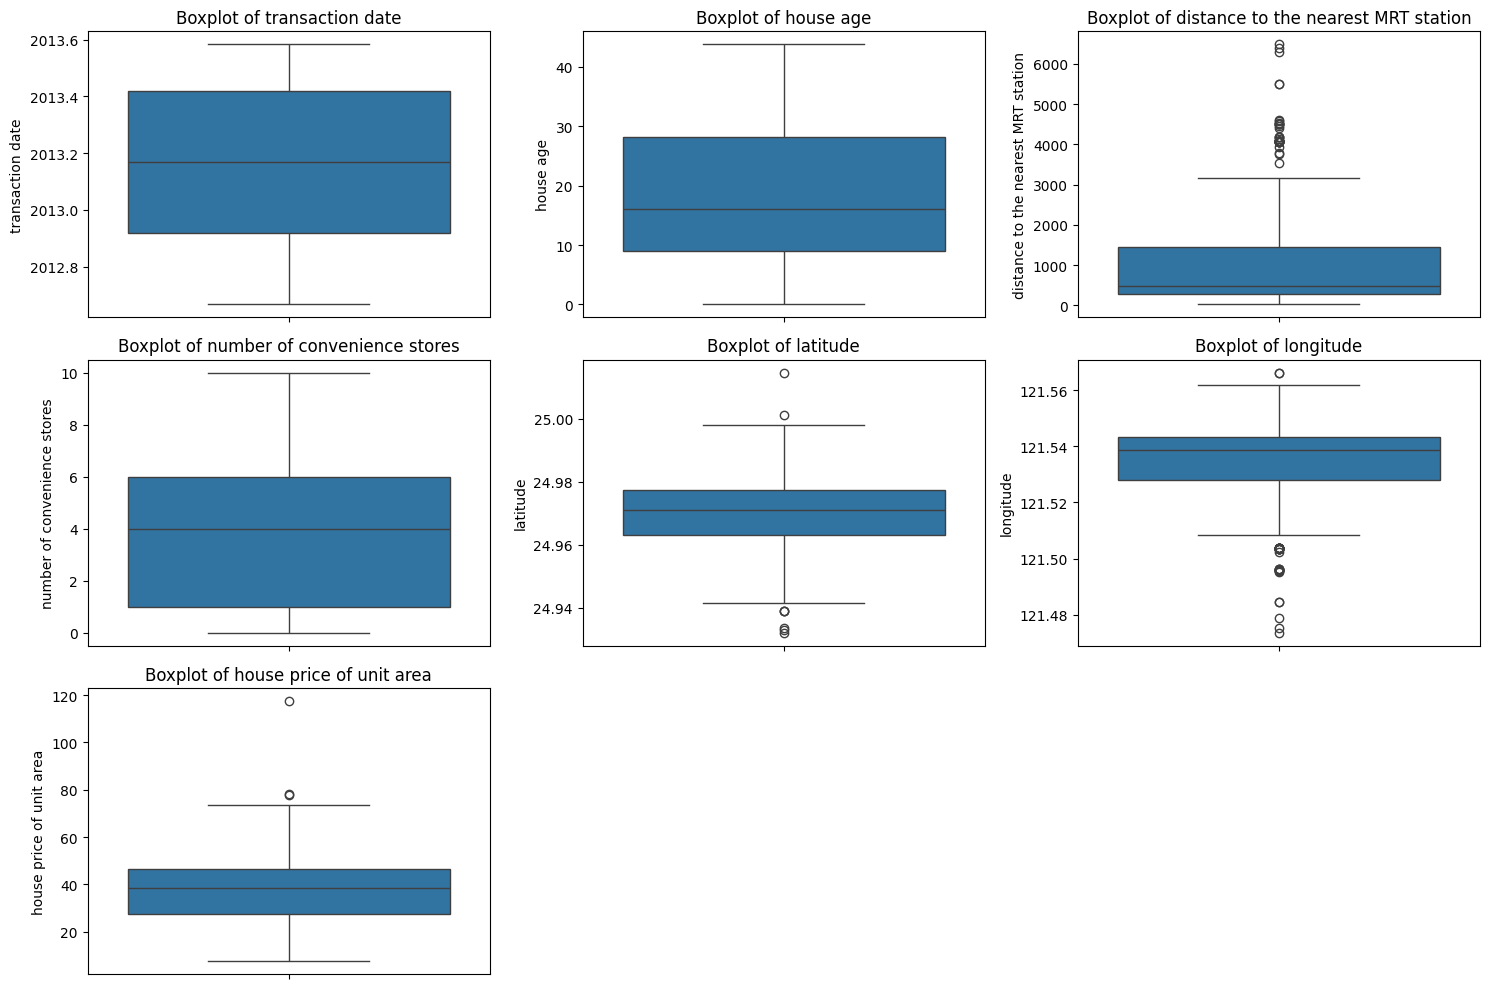

In [17]:
plt.figure(figsize=(15, 10))
all_cols_for_plot = features + [target_variable]
num_plots_per_row = 3
num_rows = int(np.ceil(len(all_cols_for_plot) / num_plots_per_row))
for i, col in enumerate(all_cols_for_plot):
    plt.subplot(num_rows, num_plots_per_row, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

Boxplot ตรวจสอบ Outliers

In [19]:
def PolynomialRegression(degree, **kwargs):
    return make_pipeline(StandardScaler(), 
                         PolynomialFeatures(degree),
                         LinearRegression(**kwargs))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_poly_2 = PolynomialRegression(degree=2)
model_poly_2.fit(X_train, y_train)
train_score_poly_2 = model_poly_2.score(X_train, y_train)
test_score_poly_2 = model_poly_2.score(X_test, y_test)
print(f"\nR-squared (Training) (Degree=9) : {train_score_poly_2:.4f}")
print(f"R-squared (Testing) (Degree=9) : {test_score_poly_2:.4f}")


R-squared (Training) (Degree=9) : 0.6901
R-squared (Testing) (Degree=9) : 0.7564


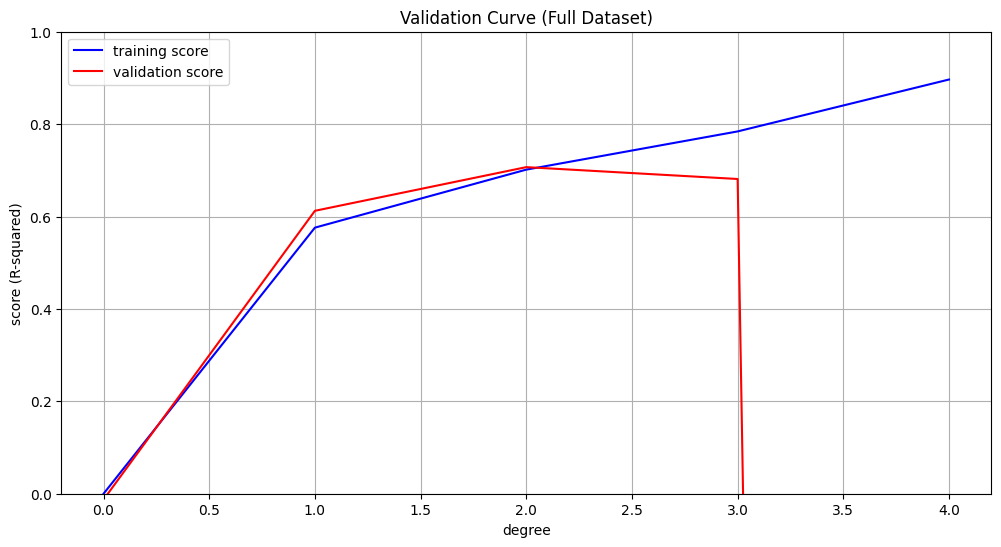

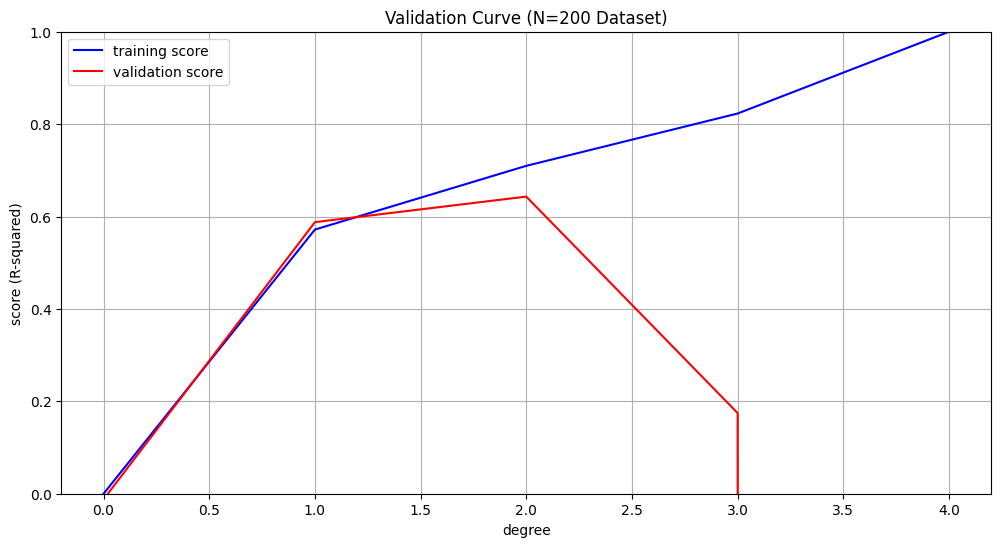

In [27]:
X_np = X.to_numpy()
y_np = y.to_numpy()

COMMON_CV = 7

degree_range_vc = np.arange(0, 5)

base_pipeline_estimator = PolynomialRegression(degree=2, fit_intercept=True) 

train_score_full, val_score_full = validation_curve(

    make_pipeline(StandardScaler(), PolynomialFeatures(), LinearRegression()), 
    X_np, y_np,
    param_name='polynomialfeatures__degree',
    param_range=degree_range_vc,
    cv=COMMON_CV, 
    scoring='r2'
)

plt.figure(figsize=(12, 6))
plt.plot(degree_range_vc, np.median(train_score_full, 1), color='blue', label='training score')
plt.plot(degree_range_vc, np.median(val_score_full, 1), color='red', label='validation score')
plt.legend(loc='best')
plt.xlabel('degree')
plt.ylabel('score (R-squared)')
plt.title('Validation Curve (Full Dataset)')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

if len(X) >= 200:
    X_200, _, y_200, _ = train_test_split(X, y, train_size=200, random_state=42, stratify=None)
    X_200_np = X_200.to_numpy()
    y_200_np = y_200.to_numpy()

    train_score_200, val_score_200 = validation_curve(
        make_pipeline(StandardScaler(), PolynomialFeatures(), LinearRegression()), 
        X_200_np, y_200_np,
        param_name='polynomialfeatures__degree',
        param_range=degree_range_vc,
        cv=COMMON_CV, 
        scoring='r2'
    )

    plt.figure(figsize=(12, 6))
    plt.plot(degree_range_vc, np.median(train_score_200, 1), color='blue', label='training score')
    plt.plot(degree_range_vc, np.median(val_score_200, 1), color='red', label='validation score')
    plt.legend(loc='best')
    plt.xlabel('degree')
    plt.ylabel('score (R-squared)')
    plt.title('Validation Curve (N=200 Dataset)')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()
else:
    print(f"จำนวนข้อมูล ({len(X)} แถว) น้อยกว่า 200 ไม่สามารถสร้าง Validation Curve สำหรับ N=200 ได้")

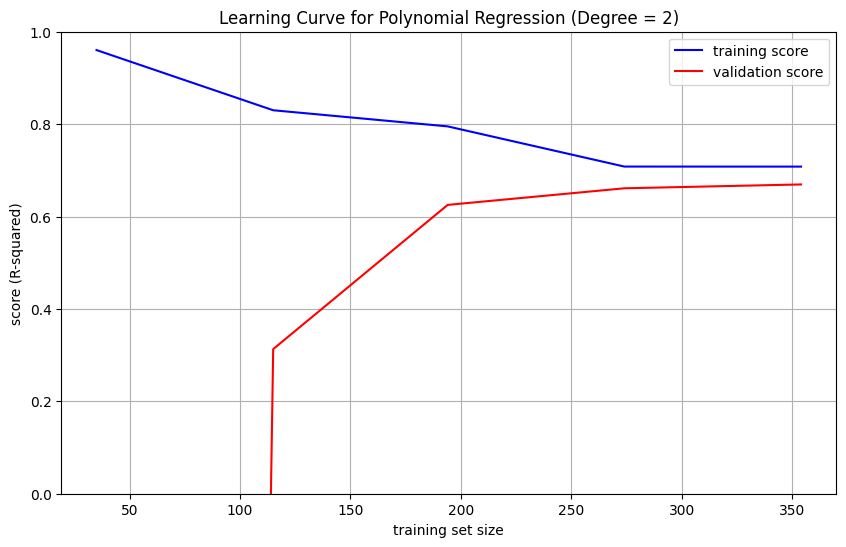

In [26]:
selected_degree_for_learning_curve = 2

model_for_learning_curve = PolynomialRegression(degree=selected_degree_for_learning_curve,
                                                fit_intercept=True)

N_train_abs, train_lc, val_lc = learning_curve(
    model_for_learning_curve, X_np, y_np,
    cv=COMMON_CV, 
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(10, 6))
plt.plot(N_train_abs, np.mean(train_lc, 1), color='blue', label='training score')
plt.plot(N_train_abs, np.mean(val_lc, 1), color='red', label='validation score')
plt.legend(loc='best')
plt.xlabel('training set size')
plt.ylabel('score (R-squared)')
plt.title(f'Learning Curve for Polynomial Regression (Degree = {selected_degree_for_learning_curve})')
plt.ylim(0, 1)
plt.grid(True)
plt.show()
